# Hello!

This notebook is used to run all the code, including training, making of predictions, and visualizations.

## Runtime set-up
The following has to be done before anything else is run. We are going to correctly set environmental settings and import Tensorflow.

In [2]:
import os

# Must be set BEFORE importing tensorflow
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"          # suppresses INFO+WARNING from C++ side
os.environ["TF_XLA_FLAGS"] = "--tf_xla_auto_jit=0"

import tensorflow as tf

# Disable XLA JIT explicitly
tf.config.optimizer.set_jit(False)
tf.debugging.set_log_device_placement(False)

# Optional: GPU memory growth (prevents TF from grabbing all VRAM at once) (I reccommend doing this, may encounter memory issues without)
gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as e:
        print(f"Could not set memory growth for {gpu}: {e}")

print("XLA JIT:", tf.config.optimizer.get_jit())
print("GPUs:", gpus)


XLA JIT: 
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


The following block will print what version of Tensorflow has been importated and what GPU devices you are running on, if any.

In [3]:
print("TF:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

TF: 2.21.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Importing functions
Below is where we import the functions needed for training and for predictions

### Importing source files:

In [4]:
import sys
sys.path.insert(0, os.path.abspath("."))  # so `source/` package is importable

import importlib

from pathlib import Path
from datetime import datetime
from tensorflow import keras
from matplotlib.ticker import MaxNLocator


In [6]:
# Source files! (import as modules)
import source_disp_frac.import_datasets as idm
import source_disp_frac.build_datasets as bd
import source_disp_frac.mapping as ma
import source_disp_frac.callbacks as cb
import source_disp_frac.train_utils as tu
import source_disp_frac.validation_util as vu
import source_disp_frac.run_config as rc
import source_disp_frac.loss_curves as lc
import source_disp_frac.predict as pred
import source_disp_frac.metrics as met
import source_disp_frac.worst_frame as wf
import source_disp_frac.plotting_metrics as pm

import source_disp_frac.predict_full_simulation_metrics as psm
import source_disp_frac.overlay_prediction_on_microstructure as opm
import source_disp_frac.plot_pred_vs_gt_contours as pgc
import source_disp_frac.plot_compare_f1_full_simulation as pcfs
import source_disp_frac.summarize_total_metrics_across_simulations as stmas
import source_disp_frac.overlay_prediction_on_microstructure_opaque as opmo


# If you edit .py source files, rerun THIS cell to pick up changes
importlib.reload(idm)
importlib.reload(bd)
importlib.reload(ma)
importlib.reload(cb)
importlib.reload(tu)
importlib.reload(vu)
importlib.reload(rc)
importlib.reload(lc)
importlib.reload(pred)
importlib.reload(met)
importlib.reload(wf)
importlib.reload(pm)
importlib.reload(psm)
importlib.reload(opm)
importlib.reload(pgc)
importlib.reload(pcfs)
importlib.reload(stmas)
importlib.reload(opmo)

<module 'source_disp_frac.overlay_prediction_on_microstructure_opaque' from '/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/CODE/source_disp_frac/overlay_prediction_on_microstructure_opaque.py'>

# RUN TRAINING

Different versions of the model can be trained. Options are the base model, and inclusion of three other variables, one at a time (pressure, von mises stress, strain energy density).

Base model: 1  
With pressure: 2  
With von mises stress: 3  
With strain energy density: 4  

### SETTINGS TO CHANGE

In [7]:
# =========================
# SELECT MODE FOR TRAINING
# =========================
MODE = 7  # 1=base, 2=+pressure, 3=+vonmises, 4=+SED, 5=predict SED and c

# =========================
# PATH WHERE DATA IS
# =========================
DATA_ROOT = Path("/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/DATASET/noRebound_NEW")

#DATA_ROOT = Path("/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/DATASET/GIT_DATASET")

# =========================
# PATH WHERE MODELS SHOULD BE SAVED
# =========================
MODEL_ROOT = Path("/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/MODEL/FRAC_DISP")

# =========================
# INPUTS INTO BASE MODEL
# =========================
cfg = {
    "feature_cols": ("x","y","ux","uy","Gc","fracture_mask"),
    "extra": None,
    
    # velocity comes from folder name, not from CSV columns
    "add_velocity": True,
    "velocity_scale": 1.0 / 1000.0,

}

### RUN

In [8]:
# For MODE = 7:
#   - no SED input
#   - predict fracture_mask + ux + uy
#   - target_cols should be ("fracture_mask", "ux", "uy")

cfg = rc.build_cfg(MODE, include_extra_in_feature_cols=True)

cfg["add_velocity"] = True
cfg["velocity_scale"] = 1.0 / 1000.0

# -------------------------
# OUTPUT PATHS (MODEL/<RUN_TAG>/...)
# -------------------------
prefix = (cfg.get("target_mode") or cfg.get("extra") or "base").lower().replace(" ", "")

RUN_TAG = f"{prefix}_{datetime.now():%Y%m%d_%H%M%S}_LARGER_RANGE"
RUN_DIR = MODEL_ROOT / RUN_TAG
RUN_DIR.mkdir(parents=True, exist_ok=True)

CKPT_DIR = RUN_DIR / "checkpoints"
CKPT_DIR.mkdir(parents=True, exist_ok=True)

CSV_LOG_PATH = RUN_DIR / "training_log.csv"

print("RUN_TAG:", RUN_TAG)
print("MODE:", MODE)
print("target_mode:", cfg["target_mode"])
print("extra_var:", cfg["extra"])
print("feature_cols:", cfg["feature_cols"])
print("target_cols:", cfg["target_cols"])
print("target_channel_names:", cfg.get("target_channel_names", None))
print("output_channels:", cfg.get("output_channels", len(cfg["target_cols"])))
print("predict_sed:", cfg.get("predict_sed", False))
print("predict_disp:", cfg.get("predict_disp", False))
print("add_velocity:", cfg.get("add_velocity", False))
print(
    "velocity_scale:", cfg.get("velocity_scale", None),
    "(e.g., V100 -> {:.3f})".format(100.0 * cfg.get("velocity_scale", 0.0))
    if cfg.get("velocity_scale") is not None else ""
)

print("RUN_DIR:", RUN_DIR)
print("Checkpoint dir:", CKPT_DIR)
print("CSV log path:", CSV_LOG_PATH)
print("DATA_ROOT:", DATA_ROOT)

# -------------------------
# Shared run settings
# -------------------------
BATCH_SIZE = 5
SEQ_LEN = 10
VAL_FRAC = 0.1

# -------------------------
# Sanity checks for MODE 7
# -------------------------
if MODE == 7:
    assert cfg["extra"] is None, f"MODE 7 should have no extra input, but got extra={cfg['extra']}"
    assert "SED" not in cfg["feature_cols"], f"MODE 7 should not include SED input. feature_cols={cfg['feature_cols']}"
    assert cfg["target_cols"] == ("fracture_mask", "ux", "uy"), f"Unexpected target_cols={cfg['target_cols']}"

# 1) Build raw datasets (point-wise windows)
datasets_raw = bd.make_datasets(
    data_root=DATA_ROOT,
    feature_cols=cfg["feature_cols"],
    target_cols=cfg["target_cols"],   # IMPORTANT: shifted future targets
    batch_size=BATCH_SIZE,
    sequence_length=SEQ_LEN,
    drop_first_csv=True,
    print_run_stats=False,
    stats_max_files_train=1,
    stats_max_files_test=None,
    add_velocity=cfg["add_velocity"],
    velocity_scale=cfg["velocity_scale"],
)

# Check raw point-wise target shape BEFORE mapping
print("\n===== RAW DATASET CHECK =====")
for X_raw, y_raw in datasets_raw["train"].take(1):
    print("X_raw shape:", X_raw.shape)
    print("y_raw shape:", y_raw.shape)
    print("Expected raw target channels:", cfg["target_cols"])
    break

# 1b) Create validation split from the TRAIN dataset
train_raw, val_raw, total_batches, val_batches = vu.split_train_val_by_batches(
    datasets_raw["train"],
    validation_fraction=VAL_FRAC,
    verbose=True,
)

datasets_raw = dict(datasets_raw)
datasets_raw["train"] = train_raw
datasets_raw["val"] = val_raw

# 2) Map ALL datasets that exist in datasets_raw
mapping_cfg = ma.MappingConfig(
    sequence_length=SEQ_LEN,
    uxuy_scale=1e4,
    binarize_masks=True,
    mask_thresh=0.5,
    binarize_after_avg=False,
)

datasets_img, grid, Cin = ma.map_existing_datasets(
    datasets_raw=datasets_raw,
    mapping_cfg=mapping_cfg,
    feature_cols=cfg["feature_cols"],
    extra_var=cfg["extra"],      # MODE 7: None
    grid_source_key="train",
    add_velocity=cfg["add_velocity"],
)

print(f"\nMapped grid: H={grid.H}, W={grid.W} | Model Cin={Cin}")

train_dataset_img = datasets_img["train"]
val_dataset_img = datasets_img["val"]

# Check mapped image target shape AFTER mapping
print("\n===== MAPPED DATASET CHECK =====")
for X_img, y_img in train_dataset_img.take(1):
    print("X_img shape:", X_img.shape)
    print("y_img shape:", y_img.shape)
    print("Expected mapped target channels:", cfg.get("target_channel_names", cfg["target_cols"]))
    break

RUN_TAG: fracture_disp_20260424_013103_LARGER_RANGE
MODE: 7
target_mode: fracture_disp
extra_var: None
feature_cols: ('x', 'y', 'ux', 'uy', 'Gc', 'fracture_mask')
target_cols: ('fracture_mask', 'ux', 'uy')
target_channel_names: ('fracture_mask', 'ux_scaled', 'uy_scaled')
output_channels: 3
predict_sed: False
predict_disp: True
add_velocity: True
velocity_scale: 0.001 (e.g., V100 -> 0.100)
RUN_DIR: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/MODEL/SED_FRAC/fracture_disp_20260424_013103_LARGER_RANGE
Checkpoint dir: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/MODEL/SED_FRAC/fracture_disp_20260424_013103_LARGER_RANGE/checkpoints
CSV log path: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/MODEL/SED_FRAC/fracture_disp_20260424_013103_LARGER_RANGE/training_log.csv
DATA_ROOT: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/DATASET/noRebound_NEW
[train] Found 4495 CSV files under /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/DATASET/noRebound_

Building can take several minutes even with GPUs, 10-20 minutes

In [9]:
# 3) Build model with computed Cin
model_cfg = ma.ModelConfig(
    sequence_length=SEQ_LEN,
    dropout=0.1,
    lr=1e-4,
    clipnorm=1.0,
    Cin=Cin,
    seed=42,
)

model = ma.build_convlstm_model(model_cfg, grid)
model.summary()

Model: "microML_convlstm_frac_disp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ seq_in (InputLayer)             │ (None, 10, 321, 161,   │             0 │
│                                 │ 7)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ clstm1 (ConvLSTM2D)             │ (None, 10, 321, 161,   │       622,592 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 10, 321, 161,   │           512 │
│ (BatchNormalization)            │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ clstm2 (ConvLSTM2D)             │ (None, 10, 321, 161,   │     1,180,160 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 10, 321, 161,   │           512 │
│ (BatchNormalization)            │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 10, 322, 162,   │             0 │
│ (TimeDistributed)               │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 10, 161, 81,    │             0 │
│ (TimeDistributed)               │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ clstm3 (ConvLSTM2D)             │ (None, 10, 161, 81,    │     1,180,160 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 161, 81,    │           512 │
│ (BatchNormalization)            │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ clstm4 (ConvLSTM2D)             │ (None, 10, 161, 81,    │     1,180,160 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 10, 161, 81,    │           512 │
│ (BatchNormalization)            │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ clstm5 (ConvLSTM2D)             │ (None, 10, 161, 81,    │     1,180,160 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 10, 161, 81,    │           512 │
│ (BatchNormalization)            │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ clstm6 (ConvLSTM2D)             │ (None, 10, 161, 81,    │     1,180,160 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 10, 161, 81,    │           512 │
│ (BatchNormalization)            │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ clstm7 (ConvLSTM2D)             │ (None, 10, 161, 81,    │     1,180,160 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 10, 161, 81,    │           51

 Total params: 7,744,899 (29.54 MB)

 Trainable params: 7,743,107 (29.54 MB)

 Non-trainable params: 1,792 (7.00 KB)

### Check inputs and output (ML target) for training

The following block can be used to double check the type of model that is going to be trained (ex. base model, pressure, von mises stress, SED)  
Can take a minute to run

In [10]:
print("\n===== DATASET INSPECTION =====")

for X_batch, y_batch in train_dataset_img.take(1):
    print("\n=== BATCH SHAPES ===")
    print("X_batch shape:", X_batch.shape)   # (B, T, H, W, Cin)
    print("y_batch shape:", y_batch.shape)   # (B, T, H, W, 1)
    print("X dtype:", X_batch.dtype)
    print("y dtype:", y_batch.dtype)

    # -------------------------------------------------
    # Build channel names from the ACTUAL config used
    # -------------------------------------------------
    mapped_channel_names = []

    # Base mapped channels in the order used by mapping.py
    # fracture_mask is target/history channel, ux/uy/Gc are inputs
    if "fracture_mask" in cfg["feature_cols"]:
        mapped_channel_names.append("fracture_mask")
    if "ux" in cfg["feature_cols"]:
        mapped_channel_names.append("ux")
    if "uy" in cfg["feature_cols"]:
        mapped_channel_names.append("uy")
    if "Gc" in cfg["feature_cols"]:
        mapped_channel_names.append("Gc")

    # Extra physics channel, if present
    extra = cfg.get("extra", None)
    if extra is not None and extra in cfg["feature_cols"]:
        mapped_channel_names.append(extra)

    # Velocity channel, if added during mapping
    if cfg.get("add_velocity", False):
        mapped_channel_names.append("velocity")

    # Coordinate channels appended during mapping
    mapped_channel_names.extend(["x_norm", "y_norm"])

    print("\n=== CHANNEL ORDER (from first mapped batch) ===")
    Cin = X_batch.shape[-1]
    for i in range(Cin):
        name = mapped_channel_names[i] if i < len(mapped_channel_names) else f"ch{i}"
        print(f"{i}: {name}")

    # Sanity check in case the listed names do not match actual Cin
    if len(mapped_channel_names) != Cin:
        print(
            f"\n[WARNING] Number of inferred channel names ({len(mapped_channel_names)}) "
            f"does not match X_batch.shape[-1] ({Cin})"
        )

    # Helper to get mapped-channel index safely
    def _mapped_ch_idx(name):
        if name in mapped_channel_names:
            return mapped_channel_names.index(name)
        return None

    # Inspect first sample in batch
    X0 = X_batch[0]
    y0 = y_batch[0]

    print("\n--- First sample ---")
    print("X0 shape:", X0.shape)
    print("y0 shape:", y0.shape)

    print("Min/Max X:", tf.reduce_min(X0).numpy(), tf.reduce_max(X0).numpy())
    print("Min/Max y:", tf.reduce_min(y0).numpy(), tf.reduce_max(y0).numpy())

    # ----- per-channel stats (first timestep) -----
    print("\n=== CHANNEL STATS (first sample, t=0) ===")
    Xt0 = X0[0]
    Cin = Xt0.shape[-1]

    for c in range(Cin):
        ch_min = tf.reduce_min(Xt0[..., c]).numpy()
        ch_max = tf.reduce_max(Xt0[..., c]).numpy()
        ch_mean = tf.reduce_mean(Xt0[..., c]).numpy()
        name = mapped_channel_names[c] if c < len(mapped_channel_names) else f"ch{c}"
        print(f"{c:>2} ({name:>12}): min={ch_min: .4e}  max={ch_max: .4e}  mean={ch_mean: .4e}")

    print("\n=== EXTRA DEBUG CHECKS (first sample, t=0) ===")

    # 1) Pressure check
    p_idx = _mapped_ch_idx("pressure")
    if p_idx is not None:
        p = Xt0[..., p_idx]
        uniq = tf.unique(tf.reshape(tf.cast(p, tf.float32), [-1]))[0]
        print(f"pressure channel index: {p_idx}")
        print("pressure unique count:", int(uniq.shape[0]))
        print("pressure first 20 unique values:", uniq.numpy()[:20])

        p_flat = tf.reshape(p, [-1])
        frac0 = tf.reduce_mean(tf.cast(tf.abs(p_flat - 0.0) < 1e-8, tf.float32)).numpy()
        frac1 = tf.reduce_mean(tf.cast(tf.abs(p_flat - 1.0) < 1e-8, tf.float32)).numpy()
        print(f"pressure fraction exactly 0: {frac0:.4f}, exactly 1: {frac1:.4f}")
    else:
        print("pressure not present in mapped input.")

    # 2) Velocity check
    v_idx = _mapped_ch_idx("velocity")
    if v_idx is not None:
        v = Xt0[..., v_idx]
        uniq_v = tf.unique(tf.reshape(tf.cast(v, tf.float32), [-1]))[0]
        print(f"velocity channel index: {v_idx}")
        print("velocity unique count:", int(uniq_v.shape[0]))
        print("velocity unique values:", uniq_v.numpy()[:20])
    else:
        print("velocity not present in mapped input.")

    # 3) Material/background proxy from Gc
    gc_idx = _mapped_ch_idx("Gc")
    if gc_idx is not None:
        material_frac = tf.reduce_mean(tf.cast(tf.abs(Xt0[..., gc_idx]) > 1e-12, tf.float32)).numpy()
        print(f"Gc channel index: {gc_idx}")
        print("fraction of grid with |Gc| > 1e-12 (material proxy):", material_frac)
    else:
        print("Gc not found in mapped input; cannot compute material proxy fraction.")

    break

print("\n===== MODEL INPUT EXPECTATION =====")
print("Model input shape:", model.input_shape)
print("Model output shape:", model.output_shape)


===== DATASET INSPECTION =====

=== BATCH SHAPES ===
X_batch shape: (5, 10, 321, 161, 7)
y_batch shape: (5, 10, 321, 161, 3)
X dtype: <dtype: 'float32'>
y dtype: <dtype: 'float32'>

=== CHANNEL ORDER (from first mapped batch) ===
0: fracture_mask
1: ux
2: uy
3: Gc
4: velocity
5: x_norm
6: y_norm

--- First sample ---
X0 shape: (10, 321, 161, 7)
y0 shape: (10, 321, 161, 3)
Min/Max X: -0.0016818914 1.0
Min/Max y: -0.0017235506 0.25195

=== CHANNEL STATS (first sample, t=0) ===
 0 (fracture_mask): min= 0.0000e+00  max= 0.0000e+00  mean= 0.0000e+00
 1 (          ux): min= 0.0000e+00  max= 2.4195e-01  mean= 9.0198e-02
 2 (          uy): min=-1.3159e-03  max= 1.2964e-03  mean= 6.6254e-07
 3 (          Gc): min= 2.7263e-02  max= 9.9443e-01  mean= 4.7023e-01
 4 (    velocity): min= 1.0000e-01  max= 1.0000e-01  mean= 1.0000e-01
 5 (      x_norm): min= 0.0000e+00  max= 1.0000e+00  mean= 5.0000e-01
 6 (      y_norm): min= 0.0000e+00  max= 1.0000e+00  mean= 5.0000e-01

=== EXTRA DEBUG CHECKS (fir

### TRAIN FROM BEGINNING

In [17]:
# =========================
# SELECT HOW MANY EPOCHS YOU WANT TO TRAIN TO
# =========================

EPOCHS_TOTAL = 70

# =========================
# SELECT HOW MANY EPOCHS TO START FROM (IF YOU'RE TRAINING FROM A CHECKPOINT)
# =========================

INITIAL_EPOCH = 27     

# =========================
# PATH FOR RE-LOADING AN ALREADY TRAINED MODEL
# =========================

#MODEL_PATH = str(CKPT_DIR / "ep050-val0.0017.keras") 

In [12]:
model, history, info = tu.train_model(
    model=model,                          # the model you already built from mapping.py
    train_dataset_img=train_dataset_img,
    val_dataset_img=val_dataset_img,
    run_dir=RUN_DIR,                      # from your MODE/path block
    epochs_total=EPOCHS_TOTAL,
    initial_epoch=0,
    model_path=None,             
)

print(info)

Epoch 1/70
770/770 ━━━━━━━━━━━━━━━━━━━━ 983s 1s/step - disp_mae_metric: 0.1960 - disp_mse_metric: 0.1179 - fracture_accuracy_metric: 0.9537 - fracture_bce_metric: 0.0857 - fracture_precision_metric: 0.5792 - fracture_recall_metric: 0.6219 - loss: 0.2036 - ux_mae_metric: 0.1330 - ux_mse_metric: 0.0645 - uy_mae_metric: 0.1167 - uy_mse_metric: 0.0534 - val_disp_mae_metric: 0.0855 - val_disp_mse_metric: 0.0122 - val_fracture_accuracy_metric: 0.9967 - val_fracture_bce_metric: 0.0109 - val_fracture_precision_metric: 0.9820 - val_fracture_recall_metric: 0.6457 - val_loss: 0.0231 - val_ux_mae_metric: 0.0673 - val_ux_mse_metric: 0.0100 - val_uy_mae_metric: 0.0388 - val_uy_mse_metric: 0.0022 - learning_rate: 1.0000e-04 - epoch_time_sec: 983.4069
Epoch 2/70
770/770 ━━━━━━━━━━━━━━━━━━━━ 930s 1s/step - disp_mae_metric: 0.1016 - disp_mse_metric: 0.0164 - fracture_accuracy_metric: 0.9964 - fracture_bce_metric: 0.0117 - fracture_precision_metric: 0.7707 - fracture_recall_metric: 0.7896 - loss: 0.0282 

### TRAIN FROM CHECKPOINT

In [15]:
model = keras.models.load_model("/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/MODEL/FRAC_DISP/fracture_disp_20260424_013103_LARGER_RANGE/checkpoints/ep027-val0.0126.keras",
                               compile=False)



In [16]:
opt = keras.optimizers.Adam(1e-4, clipnorm=1.0)
model.compile(optimizer=opt, 
                         loss="binary_crossentropy",
                          metrics=[
        tf.keras.metrics.BinaryAccuracy(threshold=0.5),
        tf.keras.metrics.Precision(thresholds=0.5),
        tf.keras.metrics.Recall(thresholds=0.5)
    ])

In [ ]:
model, history, info = tu.train_model(
    model=model,                          # can pass the existing model; will be replaced by loaded one
    train_dataset_img=train_dataset_img,
    val_dataset_img=val_dataset_img,
    run_dir=RUN_DIR,
    epochs_total=EPOCHS_TOTAL,
    initial_epoch=INITIAL_EPOCH,
    model_path="/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/MODEL/FRAC_DISP/fracture_disp_20260424_013103_LARGER_RANGE/checkpoints/ep027-val0.0126.keras",
)

print(info)

Epoch 28/70
770/770 ━━━━━━━━━━━━━━━━━━━━ 1028s 1s/step - disp_mae_metric: 0.0679 - disp_mse_metric: 0.0106 - fracture_accuracy_metric: 0.9955 - fracture_bce_metric: 0.0129 - fracture_precision_metric: 0.7376 - fracture_recall_metric: 0.7306 - loss: 0.0234 - ux_mae_metric: 0.0589 - ux_mse_metric: 0.0093 - uy_mae_metric: 0.0229 - uy_mse_metric: 0.0013 - val_disp_mae_metric: 0.0527 - val_disp_mse_metric: 0.0070 - val_fracture_accuracy_metric: 0.9971 - val_fracture_bce_metric: 0.0098 - val_fracture_precision_metric: 0.9233 - val_fracture_recall_metric: 0.6597 - val_loss: 0.0169 - val_ux_mae_metric: 0.0513 - val_ux_mse_metric: 0.0069 - val_uy_mae_metric: 0.0064 - val_uy_mse_metric: 1.2512e-04 - learning_rate: 1.0000e-04 - epoch_time_sec: 1027.9634
Epoch 29/70
770/770 ━━━━━━━━━━━━━━━━━━━━ 931s 1s/step - disp_mae_metric: 0.0674 - disp_mse_metric: 0.0110 - fracture_accuracy_metric: 0.9943 - fracture_bce_metric: 0.0157 - fracture_precision_metric: 0.6965 - fracture_recall_metric: 0.6913 - loss:

# RUN PREDICTIONS

In [313]:
print("Available datasets:", datasets_img.keys())

Available datasets: dict_keys(['train', 'test_MS206_V100', 'test_MS206_V200', 'test_MS206_V400', 'test_MS206_V1000', 'testDS_MS0_400_Vert_limRange', 'testDS_F_horizontal-layers_3_out', 'testDS_F_horizontal-layers_4_out', 'testDS_F_inclusions_1_2_out', 'testDS_F_inclusions_2_2_out', 'testDS_F_inclusions_3_2_out', 'test_MS5_150ms_inc', 'test_MS5_V400ms', 'test_F_MS210_V400_out', 'test_F_PBX_1_V400_out', 'test_F_PBX_2_V400_out', 'F_inclusions_limited_out', 'F_em_horizontal_out', 'val'])


In [314]:
# Choose which test set
TEST_NAME = "F_em_horizontal_out"  #"test_MS206_V400"
ds = datasets_img[TEST_NAME]

## Load model

In [337]:
# larger Gc range
#model = keras.models.load_model("/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/MODEL/base_20260302_175353_LARGER_RANGE/checkpoints/ep070-val0.0004.keras")


In [338]:
opt = keras.optimizers.Adam(1e-4, clipnorm=1.0)
model.compile(optimizer=opt, 
                         loss="binary_crossentropy",
                          metrics=[
        tf.keras.metrics.BinaryAccuracy(threshold=0.5),
        tf.keras.metrics.Precision(thresholds=0.5),
        tf.keras.metrics.Recall(thresholds=0.5)
    ])



## Run prediction!

In [240]:
print("Feature columns used for ds_img:")
for i, name in enumerate(cfg["feature_cols"]):
    print(f"  channel {i}: {name}")

for X_batch, y_batch in ds.take(1):
    print("\nOne batch shapes:")
    print("X_batch shape:", X_batch.shape)   # (B,T,H,W,C)
    print("y_batch shape:", y_batch.shape)   # usually (B,T,H,W,1)

Feature columns used for ds_img:
  channel 0: x
  channel 1: y
  channel 2: ux
  channel 3: uy
  channel 4: Gc
  channel 5: fracture_mask
  channel 6: SED

One batch shapes:
X_batch shape: (5, 10, 321, 161, 7)
y_batch shape: (5, 10, 321, 161, 1)


### Autoregressive prediction call

In [342]:
OUT_DIR = "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/MANUSCRIPT_TESTS/SED/F_em_horizontal_out_61"



In [343]:
df = psm.predict_full_simulation_continuous_ar_with_metrics(
    ds_img=ds,                 # your tf dataset
    model=model,               # your loaded keras model
    out_dir=OUT_DIR,
    threshold=0.5,
    csv_path=os.path.join(OUT_DIR, "per_frame_metrics.csv"),
    gt_threshold=0.5,
    frames_per_ns=10.0,
    fracture_channel_idx=0,    # change if fracture is not channel 0
    max_ar_steps=None,         # or set an integer for a shorter test
)

fracture_channel_idx_eff=0
enforce_no_healing=True


Continuous AR /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/MANUSCRIPT_TESTS/SED/F_em_horizontal_out_61: 53it [00:57,  1.09s/it]


Saved plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/MANUSCRIPT_TESTS/SED/F_em_horizontal_out_61/bce_over_time.png

Saved 265 frames to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/MANUSCRIPT_TESTS/SED/F_em_horizontal_out_61
Saved per-frame metrics CSV to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/MANUSCRIPT_TESTS/SED/F_em_horizontal_out_61/per_frame_metrics.csv
Saved BCE plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/MANUSCRIPT_TESTS/SED/F_em_horizontal_out_61/bce_over_time.png

TOTAL METRICS
TP: 397177  TN: 13090688  FP: 14  FN: 207586
Precision: 0.999965
Recall:    0.656748
F1:        0.792805
Accuracy:  0.984842
Elapsed time: 60.434 s


# RUN VISUALIZATIONS AND METRICS

## Creating fracture patterns on top of microstructure and pressure

In [347]:
# info = opm.overlay_prediction_whitespace_on_microstructure(
#     pred_dir="/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/MANUSCRIPT_TESTS/BASE/test_F_MS210_V400_out",       #"/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/NOREBOUND_NEW/SimMic_SED/testDS_MS0_400_Vert_limRange",
#     micro_path="/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/GROUND_TRUTH/finer_MS_pressure_gt",
#     out_dir="/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/FRAC_ON_MS/FOR_DEFENSE/BASE/test_F_MS210_V400_out",
#     threshold=128,
#     resize_micro=True,
#     resize_predictions=True,
#     sequence_crop_mode="border",
#     border_tol=12,
#     crop_pad_px=2,
#     crop_tb=True,
#     out_suffix="_pressure",
#     progress_every=50,
# )
# print(info)



info = opm.overlay_prediction_whitespace_on_microstructure(
    pred_dir="/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/full_masks/NOREBOUND_NEW/SimMic_SED/testDS_F_horizontal-layers_4_out",       #"/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/NOREBOUND_NEW/SimMic_SED/testDS_MS0_400_Vert_limRange",
    micro_path="/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/MS_PHOTOS/MS_vert.png",
    out_dir="/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/FRAC_ON_MS/FOR_DEFENSE/SED/testDS_F_horizontal-layers_4_out",
    threshold=128,
    resize_micro=True,
    resize_predictions=True,
    sequence_crop_mode="border",
    border_tol=12,
    crop_pad_px=2,
    crop_tb=True,
    out_suffix="_pressure_white",
    progress_every=50,
)
print(info)





Prediction image size counts:
  (161, 321): 251
Chosen target prediction size: (161, 321) (count=251)
Found 251 prediction images.
Saving to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/FRAC_ON_MS/FOR_DEFENSE/SED/testDS_F_horizontal-layers_4_out
Mode: static background image
static_crop_mode         = white
Background original size = (1110, 682)
Background cropped size  = (340, 680)
Background final size    = (161, 321)
  saved 50/251: mask_000049_pressure_white.png
  saved 100/251: mask_000099_pressure_white.png
  saved 150/251: mask_000149_pressure_white.png
  saved 200/251: mask_000199_pressure_white.png
  saved 250/251: mask_000249_pressure_white.png
  saved 251/251: mask_000250_pressure_white.png
Done.
{'mode': 'static_background', 'n_pred_files': 251, 'n_background_files': 1, 'target_size': (161, 321), 'background_original_size': (1110, 682), 'background_cropped_size': (340, 680), 'background_final_size': (161, 321), 'static_crop_mode': 'white', 'ignored_file

## Creating overlay of fracture

In [217]:

info = pgc.plot_pred_vs_gt_contours_for_simulation(
    pred_dir="/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/full_masks/NOREBOUND_NEW/SimMic_SED/real/test_MS206_V1000_ex",
    gt_dir="/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/GROUND_TRUTH/noRebound_GT_blackFrac/F_MS206_V1000",
    out_dir="/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/OVERLAY/FOR_DEFENSE/F_MS206_V1000",
    threshold=0.5,
    fracture_is="black",
    resize_if_needed=True,
    crop_gt_lr=True,
    crop_gt_tb=True,
    min_count=20,
    out_prefix="mask_",
    title_mode="none",   # "none", "filename", or "index"
    progress_every=10,
)

print(info)

Making contour overlays for 201 frame pairs.
Prediction dir: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/full_masks/NOREBOUND_NEW/SimMic_SED/real/test_MS206_V1000_ex
GT dir:         /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/GROUND_TRUTH/noRebound_GT_blackFrac/F_MS206_V1000
Output dir:     /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/OVERLAY/FOR_DEFENSE/F_MS206_V1000
  saved 10/201: mask_000009.png
  saved 20/201: mask_000019.png
  saved 30/201: mask_000029.png
  saved 40/201: mask_000039.png
  saved 50/201: mask_000049.png
  saved 60/201: mask_000059.png
  saved 70/201: mask_000069.png
  saved 80/201: mask_000079.png
  saved 90/201: mask_000089.png
  saved 100/201: mask_000099.png
  saved 110/201: mask_000109.png
  saved 120/201: mask_000119.png
  saved 130/201: mask_000129.png
  saved 140/201: mask_000139.png
  saved 150/201: mask_000149.png
  saved 160/201: mask_000159.png
  saved 170/201: mask_000169.png


### Creating opaque images of fracture on Gc

In [ ]:
importlib.reload(opmo)

<module 'source.overlay_prediction_on_microstructure_opaque' from '/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/CODE/source/overlay_prediction_on_microstructure_opaque.py'>

In [221]:

out_files = opmo.batch_overlay_single_micro(
    pred_dir="/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/MANUSCRIPT_TESTS/SED/test_F_MS210_V400_out",       #"/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/NOREBOUND_NEW/SimMic_SED/testDS_MS0_400_Vert_limRange",
    micro_path="/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/MS_PHOTOS/MS_finer.png",
    out_dir="/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/OPAQUE/FOR_DEFENSE/SED/test_F_MS210_V400_out",
    pred_glob="mask_*.png",
    unfractured_alpha=0.5,
    fracture_is="black",
    threshold=127,
    crop_micro_white_sides=True,
    crop_white_thresh=250,
    crop_tb=False,
    resize_micro_if_needed=True,
)

Saved 265 outputs to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/OPAQUE/FOR_DEFENSE/SED/test_F_MS210_V400_out


### Saving images as mp4

In [304]:
import os
import cv2
import glob


In [305]:
# frame_dir ="/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/NOREBOUND_NEW/SimMic_BASE/thesis_testDS_MS0_400_Vert_limRange"


frame_dir ="/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/FRAC_ON_MS/FOR_DEFENSE/SED/test_F_MS210_V400_out"

output_video = "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/test_F_MS210_V400_out.mp4"


# frame_dir ="/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/GROUND_TRUTH/PBX_MS_fracPressure_gt"

# output_video = "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/PBX_MS_fracPressure_gt.mp4"




In [306]:
fps = 30

# collect only pngs, but exclude non-frame images
all_pngs = sorted(glob.glob(os.path.join(frame_dir, "*.png")))

frame_files = [
    f for f in all_pngs
    if os.path.basename(f) != "bce_over_time.png"
]

if not frame_files:
    raise FileNotFoundError(f"No usable PNG frames found in {frame_dir}")

# read first valid frame
frame_example = cv2.imread(frame_files[0])
if frame_example is None:
    raise ValueError(f"Could not read first frame: {frame_files[0]}")

height, width = frame_example.shape[:2]

os.makedirs(os.path.dirname(output_video), exist_ok=True)

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
video = cv2.VideoWriter(output_video, fourcc, fps, (width, height))

if not video.isOpened():
    raise RuntimeError(f"Could not open video writer for {output_video}")

for f in frame_files:
    frame = cv2.imread(f)

    if frame is None:
        print(f"Skipping unreadable file: {f}")
        continue

    h, w = frame.shape[:2]
    if (h, w) != (height, width):
        print(f"Skipping size-mismatch frame: {f} ({w}x{h}) != ({width}x{height})")
        continue

    video.write(frame)

video.release()
print(f"Saved video to {output_video}")


Saved video to /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/test_F_MS210_V400_out.mp4


## Metrics

### Calculating metrics from ground truth (need to make into it's own source file)

In [266]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from sklearn.metrics import confusion_matrix


def load_binary_mask(path, threshold=127, white_is_positive=True):
    """
    Load image as binary mask.

    Parameters
    ----------
    path : str or Path
        Image path.
    threshold : int
        Grayscale threshold in [0,255].
    white_is_positive : bool
        If True, white pixels -> 1 and black -> 0.
        If False, black pixels -> 1 and white -> 0.

    Returns
    -------
    mask : np.ndarray, uint8
        2D array with values 0 or 1.
    """
    img = Image.open(path).convert("L")
    arr = np.array(img)

    if white_is_positive:
        mask = (arr > threshold).astype(np.uint8)
    else:
        mask = (arr <= threshold).astype(np.uint8)

    return mask


def find_crop_from_first_black(gt_img_gray, black_threshold=10):
    """
    Find crop bounds using the first black pixels from top, bottom, left, right.

    This treats 'black' as pixel intensity <= black_threshold.

    Parameters
    ----------
    gt_img_gray : np.ndarray
        2D grayscale image (0..255).
    black_threshold : int
        Threshold for deciding whether a pixel is black.

    Returns
    -------
    top, bottom, left, right : int
        Crop bounds such that cropped image is gt[top:bottom, left:right]
    """
    if gt_img_gray.ndim != 2:
        raise ValueError(f"Expected 2D grayscale image, got shape {gt_img_gray.shape}")

    H, W = gt_img_gray.shape
    black = gt_img_gray <= black_threshold

    # first row from top containing any black pixel
    top = 0
    while top < H and not black[top, :].any():
        top += 1

    # first row from bottom containing any black pixel
    bottom = H - 1
    while bottom >= 0 and not black[bottom, :].any():
        bottom -= 1

    # first col from left containing any black pixel
    left = 0
    while left < W and not black[:, left].any():
        left += 1

    # first col from right containing any black pixel
    right = W - 1
    while right >= 0 and not black[:, right].any():
        right -= 1

    if top > bottom or left > right:
        raise ValueError("Could not determine valid crop bounds from black border.")

    # python slice end is exclusive
    return top, bottom + 1, left, right + 1


def crop_gt_and_pred_from_gt_black_border(gt_path, pred_path, black_threshold=10):
    """
    Crop GT based on first black pixels from each side, then resize the cropped GT
    to match the prediction shape.

    Prediction is used as-is.

    Returns
    -------
    gt_resized_bin : np.ndarray
        Cropped + resized binary GT mask, same shape as prediction.
    pred_bin : np.ndarray
        Binary prediction mask.
    crop_info : dict
        Crop and resize metadata.
    """
    gt_img = Image.open(gt_path).convert("L")
    pred_img = Image.open(pred_path).convert("L")

    gt_gray = np.array(gt_img)
    pred_gray = np.array(pred_img)

    # 1) Find crop bounds from full GT
    top, bottom, left, right = find_crop_from_first_black(
        gt_gray, black_threshold=black_threshold
    )

    # 2) Crop GT
    gt_crop_gray = gt_gray[top:bottom, left:right]

    # 3) Resize cropped GT to prediction shape using nearest-neighbor
    pred_h, pred_w = pred_gray.shape
    gt_crop_pil = Image.fromarray(gt_crop_gray)
    gt_resized_gray = np.array(
        gt_crop_pil.resize((pred_w, pred_h), resample=Image.NEAREST)
    )

    # 4) Convert both to binary
    gt_resized_bin = (gt_resized_gray > 127).astype(np.uint8)
    pred_bin = (pred_gray > 127).astype(np.uint8)

    crop_info = {
        "top": top,
        "bottom": bottom,
        "left": left,
        "right": right,
        "gt_full_h": gt_gray.shape[0],
        "gt_full_w": gt_gray.shape[1],
        "gt_crop_h": gt_crop_gray.shape[0],
        "gt_crop_w": gt_crop_gray.shape[1],
        "pred_h": pred_gray.shape[0],
        "pred_w": pred_gray.shape[1],
        "gt_resized_h": gt_resized_bin.shape[0],
        "gt_resized_w": gt_resized_bin.shape[1],
    }

    return gt_resized_bin, pred_bin, crop_info

def metrics_from_binary(y_true_1d, y_pred_1d):
    """
    Compute binary classification metrics and confusion counts.
    """
    cm = confusion_matrix(y_true_1d, y_pred_1d, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0
    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0.0

    return {
        "tp": int(tp),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "accuracy": float(accuracy),
    }


def get_image_files(folder, exts=(".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp")):
    """
    Return dict mapping filename -> full path for supported image files.
    """
    folder = Path(folder)
    files = {}
    for p in sorted(folder.iterdir()):
        if p.is_file() and p.suffix.lower() in exts:
            files[p.name] = str(p)
    return files


def compute_metrics_from_folders(
    gt_dir,
    pred_dir,
    output_csv=None,
    black_threshold=10,
    verbose=True,
):
    """
    Compute per-image and overall metrics from GT and prediction folders.

    GT is cropped using first black pixels from top/left/right/bottom,
    and the same crop is applied to prediction.

    Matching behavior
    -----------------
    Files are matched by sorted order, NOT by exact filename.
    This is useful when GT and prediction folders use different naming conventions.
    """
    gt_files = get_image_files(gt_dir)
    pred_files = get_image_files(pred_dir)

    gt_names = sorted(gt_files.keys())
    pred_names = sorted(pred_files.keys())

    if len(gt_names) == 0:
        raise ValueError(f"No image files found in gt_dir: {gt_dir}")
    if len(pred_names) == 0:
        raise ValueError(f"No image files found in pred_dir: {pred_dir}")

    n_match = min(len(gt_names), len(pred_names))

    if verbose:
        print(f"GT files:   {len(gt_names)}")
        print(f"Pred files: {len(pred_names)}")
        print(f"Using first {n_match} pairs matched by sorted order.")

        if len(gt_names) != len(pred_names):
            print(
                "WARNING: GT and prediction folders have different numbers of files. "
                "Only the minimum count will be used."
            )

        print("\nFirst few matched pairs:")
        for i in range(min(5, n_match)):
            print(f"  GT:   {gt_names[i]}")
            print(f"  Pred: {pred_names[i]}")
            print()

    rows = []
    TP = TN = FP = FN = 0

    for i in range(n_match):
        gt_name = gt_names[i]
        pred_name = pred_names[i]

        gt_path = gt_files[gt_name]
        pred_path = pred_files[pred_name]

        gt_bin, pred_bin, crop_info = crop_gt_and_pred_from_gt_black_border(
            gt_path,
            pred_path,
            black_threshold=black_threshold,
        )

        if gt_bin.shape != pred_bin.shape:
            raise ValueError(
                f"Shape mismatch after cropping for pair index {i}: "
                f"GT file {gt_name} -> {gt_bin.shape}, "
                f"Pred file {pred_name} -> {pred_bin.shape}"
            )

        yt = gt_bin.reshape(-1)
        yp = pred_bin.reshape(-1)

        m = metrics_from_binary(yt, yp)

        TP += m["tp"]
        TN += m["tn"]
        FP += m["fp"]
        FN += m["fn"]

        row = {
            "pair_idx": i,
            "gt_filename": gt_name,
            "pred_filename": pred_name,
            "n_pixels": int(yt.size),
            **crop_info,
            **m,
        }
        rows.append(row)

    df = pd.DataFrame(rows)

    overall_precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    overall_recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    overall_f1 = (
        2 * overall_precision * overall_recall / (overall_precision + overall_recall)
        if (overall_precision + overall_recall) > 0
        else 0.0
    )
    overall_accuracy = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0.0

    overall = {
        "tp": int(TP),
        "tn": int(TN),
        "fp": int(FP),
        "fn": int(FN),
        "precision": float(overall_precision),
        "recall": float(overall_recall),
        "f1": float(overall_f1),
        "accuracy": float(overall_accuracy),
    }

    if output_csv is not None:
        df.to_csv(output_csv, index=False)
        if verbose:
            print(f"Saved per-image metrics to: {output_csv}")

    if verbose:
        print("\nOVERALL METRICS")
        print(f"TP: {overall['tp']}")
        print(f"TN: {overall['tn']}")
        print(f"FP: {overall['fp']}")
        print(f"FN: {overall['fn']}")
        print(f"Precision: {overall['precision']:.6f}")
        print(f"Recall:    {overall['recall']:.6f}")
        print(f"F1:        {overall['f1']:.6f}")
        print(f"Accuracy:  {overall['accuracy']:.6f}")

    return df, overall

In [358]:
gt_dir = "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/GROUND_TRUTH/F_MS206_V100"
pred_dir = "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/SimMic_SED/test_MS206_V100"

df_metrics, overall = compute_metrics_from_folders(
    gt_dir=gt_dir,
    pred_dir=pred_dir,
    output_csv="per_image_metrics.csv",
    black_threshold=10,
    verbose=True,
)

GT files:   650
Pred files: 635
Using first 635 pairs matched by sorted order.

First few matched pairs:
  GT:   F_MS106_V100.0001.png
  Pred: mask_000000.png

  GT:   F_MS106_V100.0002.png
  Pred: mask_000001.png

  GT:   F_MS106_V100.0003.png
  Pred: mask_000002.png

  GT:   F_MS106_V100.0004.png
  Pred: mask_000003.png

  GT:   F_MS106_V100.0005.png
  Pred: mask_000004.png

Saved per-image metrics to: per_image_metrics.csv

OVERALL METRICS
TP: 60409
TN: 32644763
FP: 0
FN: 112263
Precision: 1.000000
Recall:    0.349848
F1:        0.518352
Accuracy:  0.996579


In [261]:
gt_files = get_image_files(gt_dir)
pred_files = get_image_files(pred_dir)

print("First 10 GT filenames:")
for k in list(gt_files.keys())[:10]:
    print(k)

print("\nFirst 10 prediction filenames:")
for k in list(pred_files.keys())[:10]:
    print(k)

First 10 GT filenames:
F_MS106_V400.0001.png
F_MS106_V400.0002.png
F_MS106_V400.0003.png
F_MS106_V400.0004.png
F_MS106_V400.0005.png
F_MS106_V400.0006.png
F_MS106_V400.0007.png
F_MS106_V400.0008.png
F_MS106_V400.0009.png
F_MS106_V400.0010.png

First 10 prediction filenames:
mask_000000.png
mask_000001.png
mask_000002.png
mask_000003.png
mask_000004.png
mask_000005.png
mask_000006.png
mask_000007.png
mask_000008.png
mask_000009.png


### Printing metrics calculated already from csv file and printing

In [359]:
id="gd1kmz"
import pandas as pd

csv_path = "per_image_metrics.csv"   # or replace with full path

df = pd.read_csv(csv_path)

TP = int(df["tp"].sum())
TN = int(df["tn"].sum())
FP = int(df["fp"].sum())
FN = int(df["fn"].sum())

precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
f1        = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0
accuracy  = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0.0

print("TOTAL METRICS")
print(f"TP: {TP}  TN: {TN}  FP: {FP}  FN: {FN}")
print(f"Precision: {precision:.6f}")
print(f"Recall:    {recall:.6f}")
print(f"F1:        {f1:.6f}")
print(f"Accuracy:  {accuracy:.6f}")

TOTAL METRICS
TP: 60409  TN: 32644763  FP: 0  FN: 112263
Precision: 1.000000
Recall:    0.349848
F1:        0.518352
Accuracy:  0.996579


### Metrics across Base and Base + SED

In [369]:
csv_map = {
    "Base": {
        "100 m/s": "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/SimMic_BASE/test_MS206_V100/per_frame_metrics.csv",
        "200 m/s": "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/SimMic_BASE/test_MS206_V200/per_frame_metrics.csv",
        "400 m/s": "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/SimMic_BASE/test_MS206_V400/per_frame_metrics.csv",#"/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/TEST/forBase/testBase_MS206_V400/per_frame_metrics.csv",
        "1000 m/s": "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/SimMic_BASE/test_MS206_V1000/per_frame_metrics.csv",
    },
    "Base + SED": {
        "100 m/s": "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/SimMic_SED/test_MS206_V100/per_frame_metrics.csv",
        "200 m/s": "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/SimMic_SED/test_MS206_V200/per_frame_metrics.csv",
    "400 m/s":"/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/SimMic_SED/test_MS206_V400/per_frame_metrics.csv",
     #   "400 m/s": "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/TEST/forSED/test70epoch_test_MS206_V400/per_frame_metrics.csv",
        "1000 m/s": "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/SimMic_SED/test_MS206_V1000/per_frame_metrics.csv",
    },
}

In [84]:
results = stmas.summarize_total_metrics_across_simulations(
    csv_map=csv_map,
    print_results=True,
)

results


TOTAL METRICS ACROSS SIMULATIONS

MODEL: Base
--------------------------------------------------------------------------------
Number of simulations: 4
Total rows summed:     2200
TP: 8662142
TN: 103838865
FP: 3588
FN: 1193605
Precision: 0.999586
Recall:    0.878892
F1:        0.935362
Accuracy:  0.989470

Per-simulation totals:
   100 m/s | TP=142228  TN=31104912  FP=93  FN=19772  F1=0.934724
   200 m/s | TP=1230438  TN=29847698  FP=395  FN=188474  F1=0.928722
   400 m/s | TP=3828944  TN=27015258  FP=975  FN=421828  F1=0.947677
  1000 m/s | TP=3460532  TN=15870997  FP=2125  FN=563531  F1=0.924445

MODEL: Base + SED
--------------------------------------------------------------------------------
Number of simulations: 4
Total rows summed:     2200
TP: 8587111
TN: 103840563
FP: 1890
FN: 1268636
Precision: 0.999780
Recall:    0.871280
F1:        0.931117
Accuracy:  0.988825

Per-simulation totals:
   100 m/s | TP=141405  TN=31104967  FP=38  FN=20595  F1=0.932004
   200 m/s | TP=1216874 

{'Base': {'tp': 8662142,
  'tn': 103838865,
  'fp': 3588,
  'fn': 1193605,
  'precision': 0.9995859552513175,
  'recall': 0.8788924878043237,
  'f1': 0.9353619044528684,
  'accuracy': 0.9894704313700656,
  'model': 'Base',
  'n_simulations': 4,
  'total_rows': 2200,
  'per_simulation': [{'tp': 142228,
    'tn': 31104912,
    'fp': 93,
    'fn': 19772,
    'precision': 0.9993465475931169,
    'recall': 0.8779506172839506,
    'f1': 0.9347235320598972,
    'accuracy': 0.9993646657234999,
    'simulation': '100 m/s',
    'csv_path': '/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/TEST/forBase/testBase_MS206_V100/per_frame_metrics.csv',
    'n_rows': 605},
   {'tp': 1230438,
    'tn': 29847698,
    'fp': 395,
    'fn': 188474,
    'precision': 0.9996790791277127,
    'recall': 0.867170057057802,
    'f1': 0.9287218204015858,
    'accuracy': 0.993959479009902,
    'simulation': '200 m/s',
    'csv_path': '/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/TES

### Plotting metric comparisons for Base + Base + SED

In [256]:
importlib.reload(pcfs)

<module 'source.plot_compare_f1_full_simulation' from '/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/CODE/source/plot_compare_f1_full_simulation.py'>

In [266]:
out_dir = "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/FOR_DEFENSE/"

In [267]:
csv_map = {
    "ML": {
        "100 m/s": "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/full_masks/NOREBOUND_NEW/SimMic_SED/test_MS206_V400/per_frame_metrics.csv",
       # "200 m/s": "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/full_masks/SimMic_BASE/test_MS206_V200/per_frame_metrics.csv",
       # "400 m/s": "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/full_masks/SimMic_BASE/test_MS206_V400/per_frame_metrics.csv",#"/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/TEST/forBase/testBase_MS206_V400/per_frame_metrics.csv",
       # "1000 m/s": "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/full_masks/SimMic_BASE/test_MS206_V1000/per_frame_metrics.csv",
    },
    "ML + SED": {
        "100 m/s": "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/full_masks/NOREBOUND_NEW/SimMic_SED/test_MS206_V400/per_frame_metrics.csv",
        #"200 m/s": "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/full_masks/SimMic_SED/test_MS206_V200/per_frame_metrics.csv",
    #"400 m/s":"/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/full_masks/SimMic_SED/test_MS206_V400/per_frame_metrics.csv",
     #   "400 m/s": "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/TEST/forSED/test70epoch_test_MS206_V400/per_frame_metrics.csv",
       # "1000 m/s": "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/full_masks/SimMic_SED/test_MS206_V1000/per_frame_metrics.csv",
    },
}

In [268]:
loss_csv_map = {
    "ML": "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/MODEL/NOREBOUND_NEW/base_20260322_175523_LARGER_RANGE/training_log.csv",
    "ML + SED": "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/MODEL/NOREBOUND_NEW/sed_20260322_175447_LARGER_RANGE/training_log.csv",
}

# "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/MODEL/NOREBOUND_NEW/base_20260322_175523_LARGER_RANGE/checkpoints/ep072-val0.0044.keras")
#model = keras.models.load_model("/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/MODEL/NOREBOUND/base_20260321_151616_LARGER_RANGE/checkpoints/ep052-val0.0002.keras")

In [269]:
info = pcfs.plot_f1_full_simulation_comparison(
    csv_map=csv_map,
    out_dir=out_dir,
    loss_csv_map=loss_csv_map,
    show=False,
    linewidth=2.5,
    colors_all=["blue", "green", "darkviolet", "dodgerblue", "limegreen", "violet"],
    colors_base=["blue", "green", "darkviolet"],
    colors_sed=["dodgerblue", "limegreen", "violet"],
    individual_color="purple",
    loss_colors=["darkgreen", "royalblue"],   # Base, Base + SED
    time_scale=1
)

Saved plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/FOR_DEFENSE/f1_full_simulation_comparison.png
Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/FOR_DEFENSE/individual_f1_plots/f1_over_time_ml_100_m_s.png
Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/FOR_DEFENSE/individual_f1_plots/f1_over_time_ml_plus_sed_100_m_s.png
Saved plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/FOR_DEFENSE/bce_full_simulation_comparison.png
Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/FOR_DEFENSE/individual_bce_plots/bce_over_time_ml_100_m_s.png
Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/FOR_DEFENSE/individual_bce_plots/bce_over_time_ml_plus_sed_100_m_s.png
Saved plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/FOR_DEFENSE/incorrect_predictions_full_si

### F1 across Base and Base + SED

In [396]:
out_dir = "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR"



In [425]:
csv_map = {
    "Base": {
        "100 m/s": "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/SimMic_BASE/test_MS206_V100/per_frame_metrics.csv",
        "200 m/s": "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/SimMic_BASE/test_MS206_V200/per_frame_metrics.csv",
        "400 m/s": "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/SimMic_BASE/test_MS206_V400/per_frame_metrics.csv",#"/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/TEST/forBase/testBase_MS206_V400/per_frame_metrics.csv",
        "1000 m/s": "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/SimMic_BASE/test_MS206_V1000/per_frame_metrics.csv",
    },
    "Base + SED": {
        "100 m/s": "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/SimMic_SED/test_MS206_V100/per_frame_metrics.csv",
        "200 m/s": "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/SimMic_SED/test_MS206_V200/per_frame_metrics.csv",
    "400 m/s":"/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/SimMic_SED/test_MS206_V400/per_frame_metrics.csv",
     #   "400 m/s": "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/TEST/forSED/test70epoch_test_MS206_V400/per_frame_metrics.csv",
        "1000 m/s": "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/SimMic_SED/test_MS206_V1000/per_frame_metrics.csv",
    },
}


In [ ]:
info = pcfs.plot_f1_full_simulation_comparison(
    csv_map=csv_map,
    out_dir=out_dir,
    show=True,
    linewidth=2.5,
    colors_all=["blue", "tomato", "green", "darkviolet", "dodgerblue", "lightsalmon", "limegreen", "violet"],
    colors_base=["blue", "lightsalmon", "green", "darkviolet"],
    colors_sed=["dodgerblue", "red", "limegreen", "violet"],
    individual_color="purple",
    time_scale=1
)

Saved plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/FOR_DEFENSE/f1_full_simulation_comparison.png
Saved plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/FOR_DEFENSE/f1_full_simulation_base_only.png
Saved plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/FOR_DEFENSE/f1_full_simulation_base_plus_sed_only.png
Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/FOR_DEFENSE/individual_f1_plots/f1_over_time_base_100_m_s.png
Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/FOR_DEFENSE/individual_f1_plots/f1_over_time_base_400_m_s.png
Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/FOR_DEFENSE/individual_f1_plots/f1_over_time_base_1000_m_s.png
Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/FOR_DEFENSE/individual_f1_plots/f1_over_time_base_plus_sed_100_m

ValueError: CSV missing required columns {'bce'}: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/full_masks/SimMic_BASE/test_MS206_V100/per_frame_metrics.csv

<Figure size 1400x800 with 0 Axes>

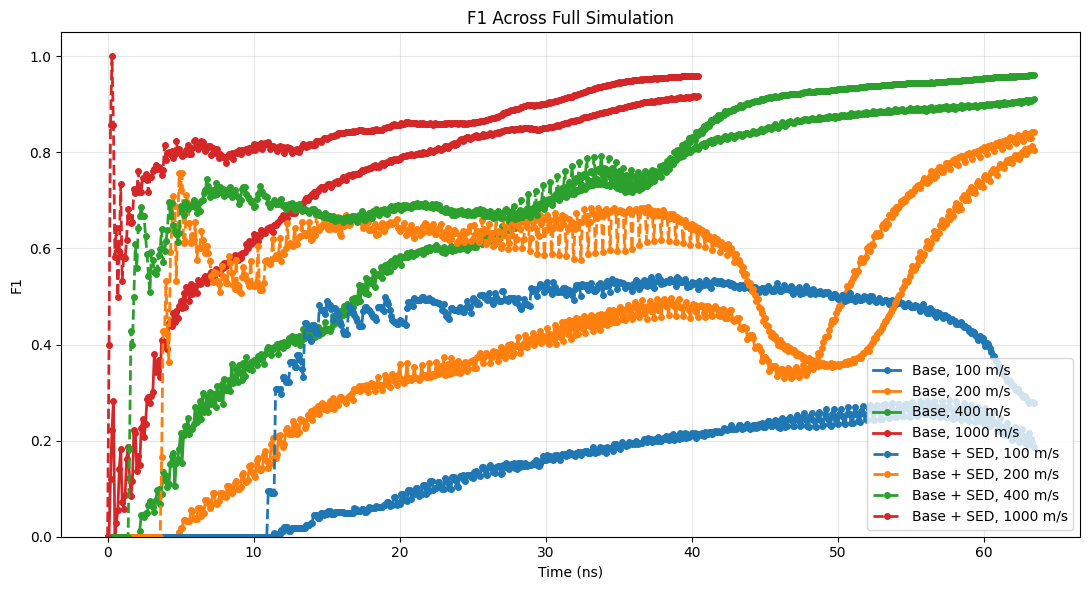

Saved plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR/f1_full_simulation_comparison.png


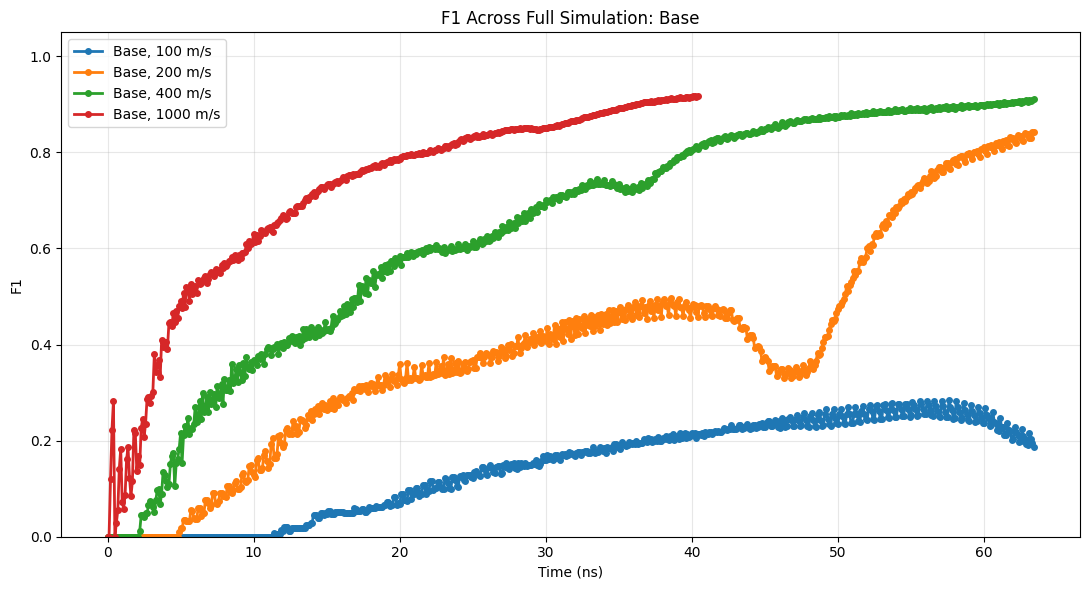

Saved plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR/f1_full_simulation_base_only.png


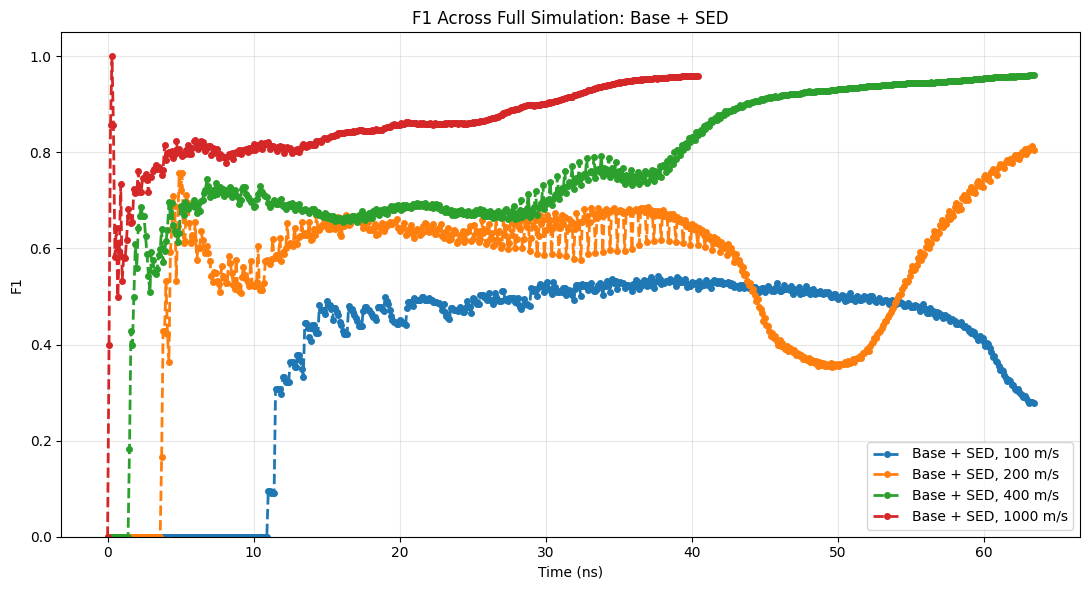

Saved plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR/f1_full_simulation_base_plus_sed_only.png


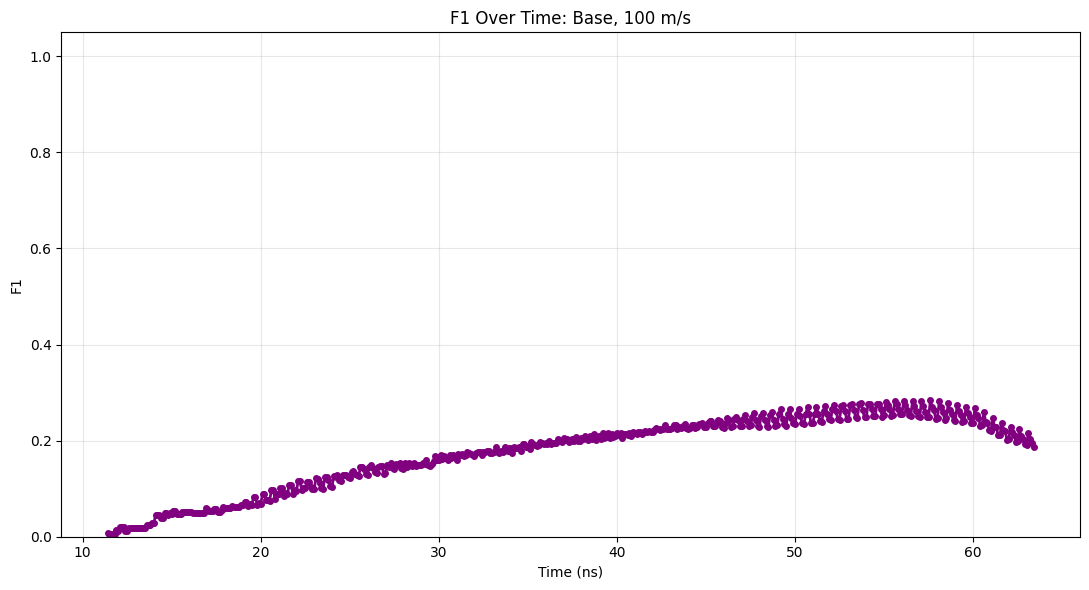

Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare/individual_plots/f1_over_time_base_100_m_s.png


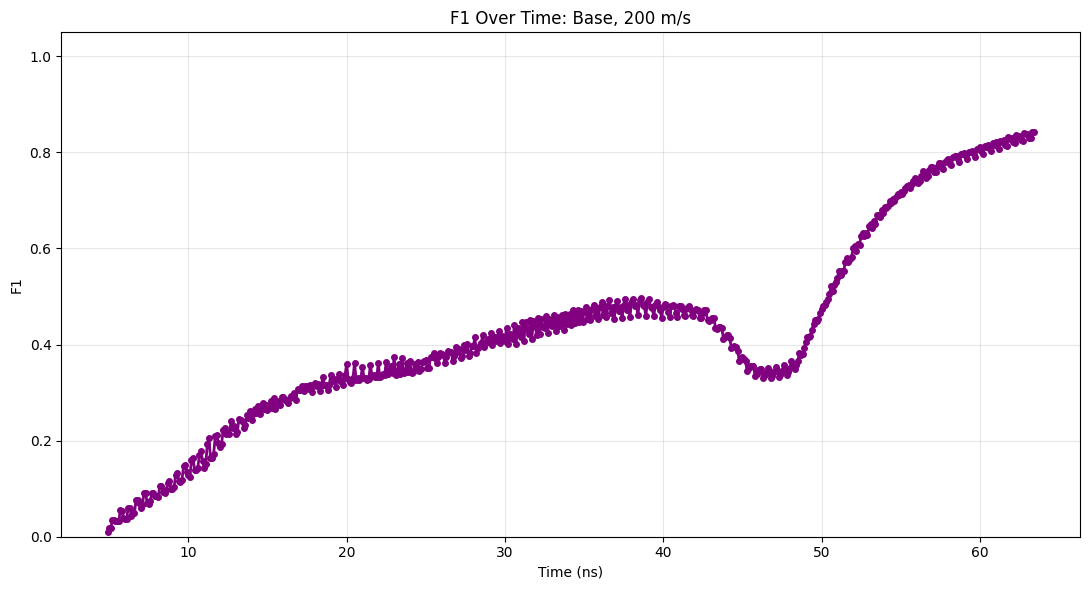

Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare/individual_plots/f1_over_time_base_200_m_s.png


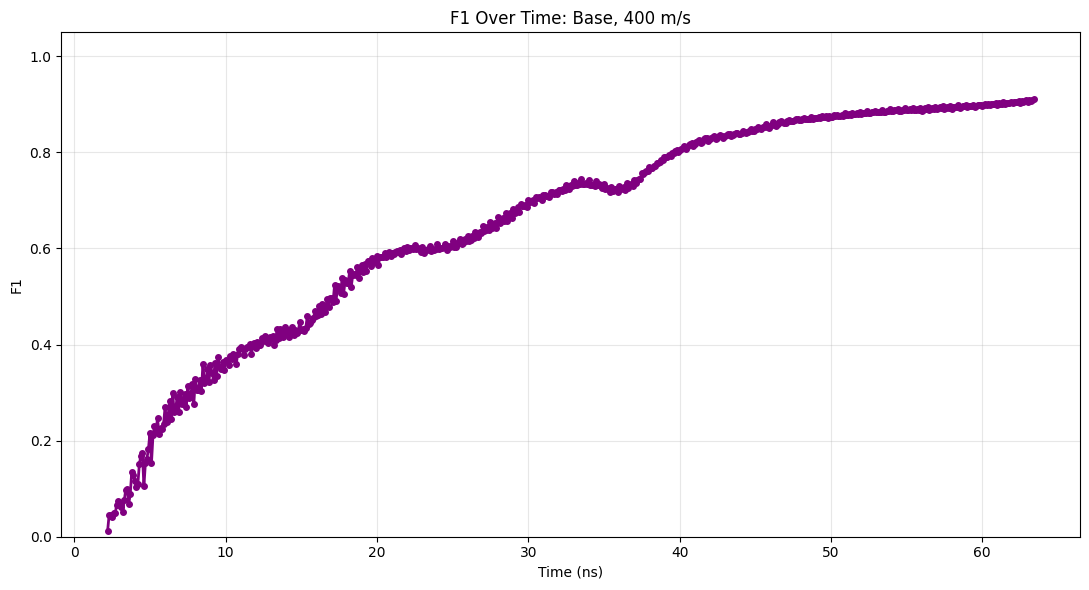

Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare/individual_plots/f1_over_time_base_400_m_s.png


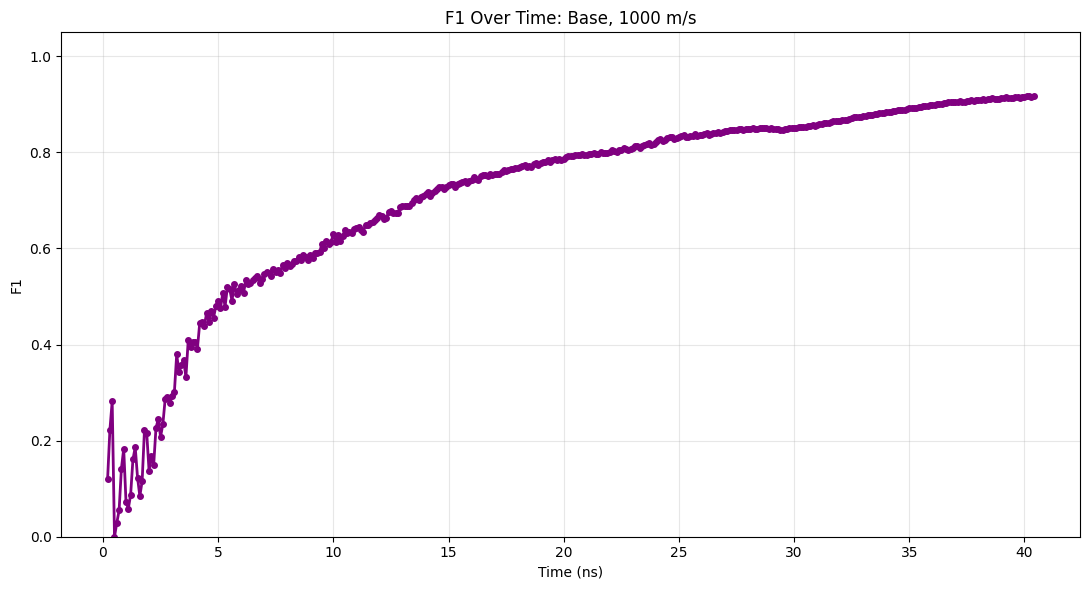

Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare/individual_plots/f1_over_time_base_1000_m_s.png


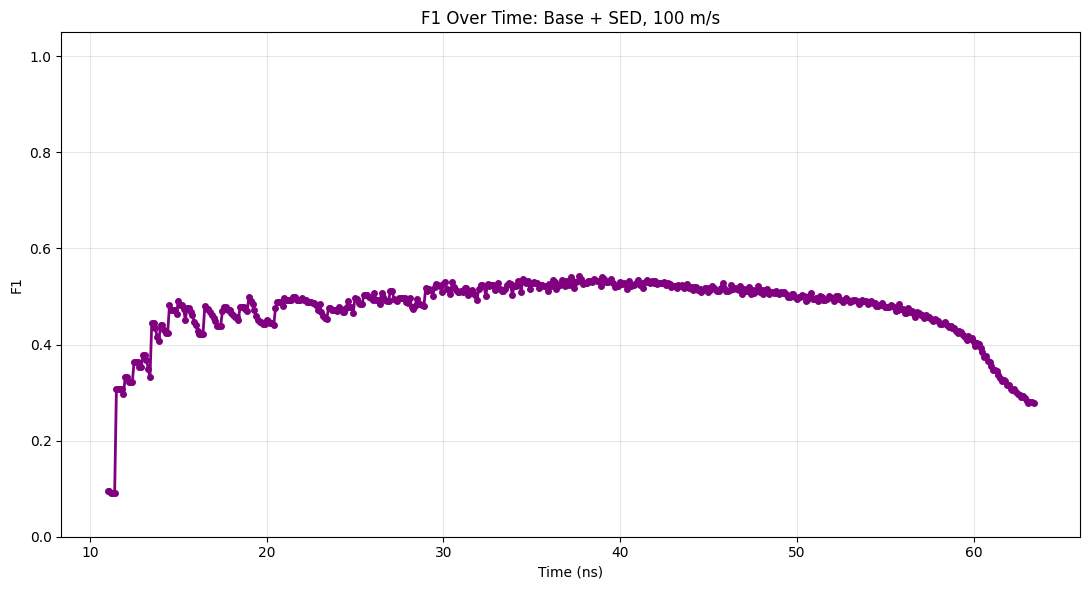

Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare/individual_plots/f1_over_time_base_plus_sed_100_m_s.png


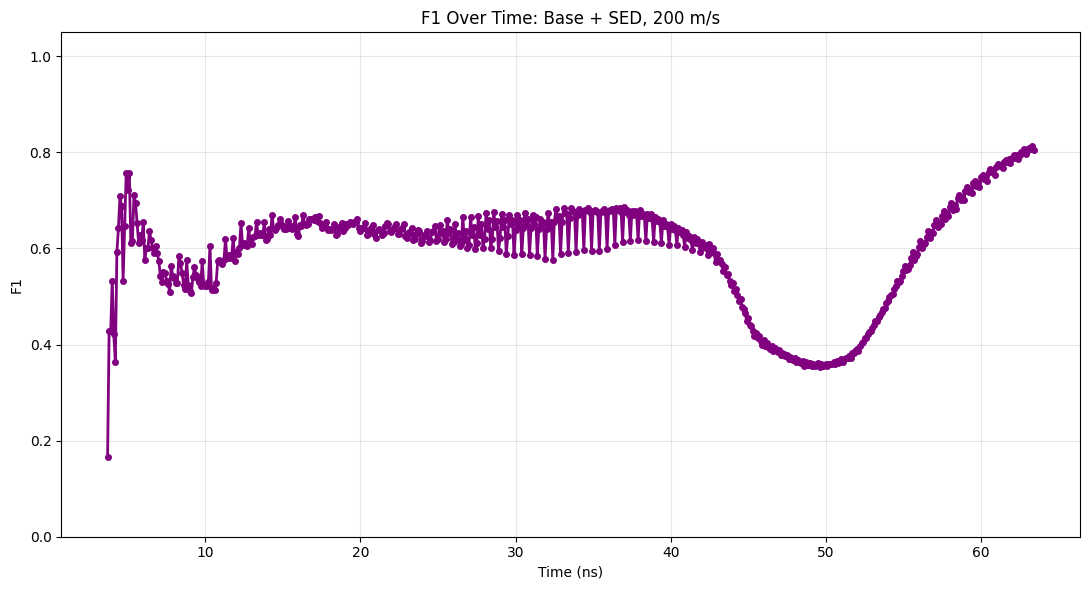

Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare/individual_plots/f1_over_time_base_plus_sed_200_m_s.png


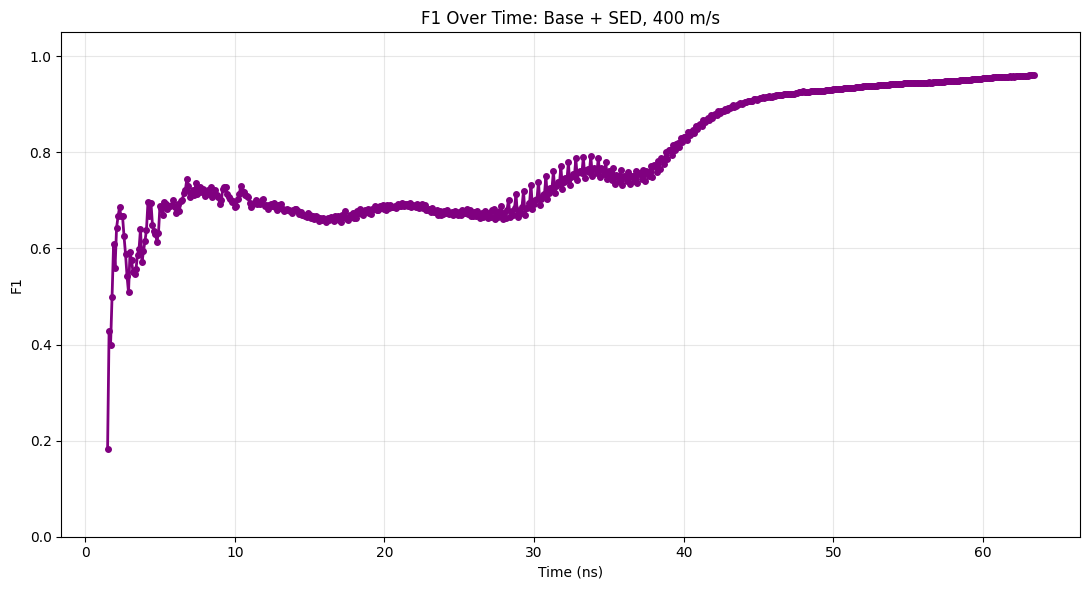

Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare/individual_plots/f1_over_time_base_plus_sed_400_m_s.png


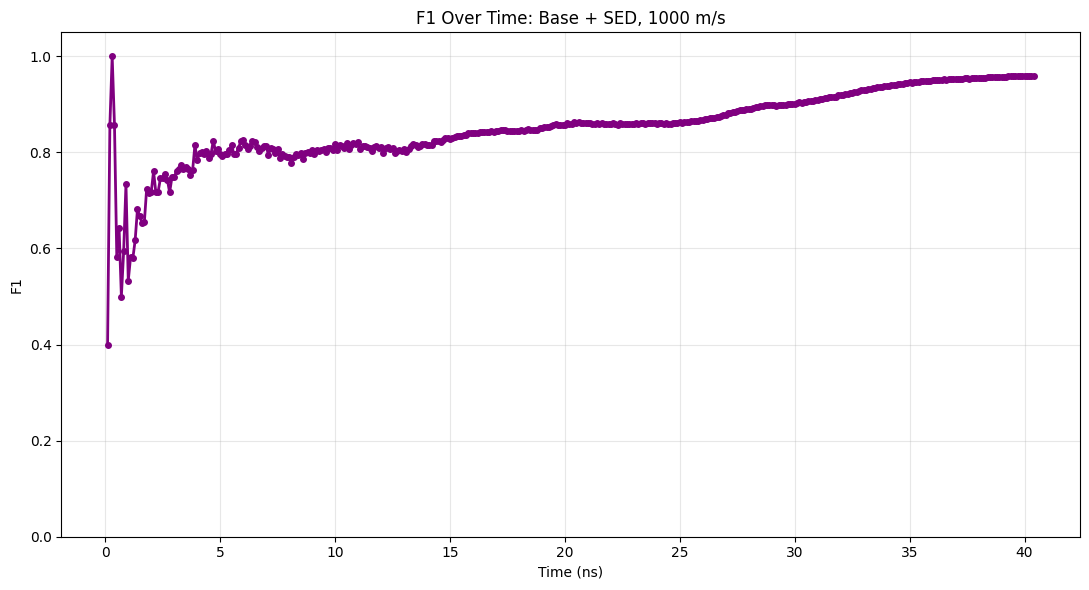

Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare/individual_plots/f1_over_time_base_plus_sed_1000_m_s.png


{'all_plot_path': '/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR/f1_full_simulation_comparison.png',
 'base_plot_path': '/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR/f1_full_simulation_base_only.png',
 'base_plus_sed_plot_path': '/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR/f1_full_simulation_base_plus_sed_only.png',
 'individual_plot_dir': '/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare/individual_plots',
 'individual_plot_count': 8,
 'individual_plot_info': [{'model': 'Base',
   'velocity': '100 m/s',
   'csv_path': '/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/SimMic_BASE/test_MS206_V100/per_frame_metrics.csv',
   'plot_path': '/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare/individual_plots/f1_over_time_base_100_m_s.png',
   'started_from_positive_f1': True},
  {'model': 'Base',
   '

In [371]:
info = pcfs.plot_f1_full_simulation_comparison(
    csv_map=csv_map,
    out_dir="/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR",
    individual_out_dir="/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare/individual_plots",
    time_scale=1.0,
    show=True,
)

info

### metric calc

In [ ]:
#PRED_DIR = "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/Metrics/sed_test"
PRED_DIR = "/scratch/gilbreth/kmartinu/microML/undeformed_preds_MS5_125"
GT_DIR   = "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/GROUND_TRUTH/MS5_125"
OUT_CSV  = "microML/MS5_125_metrics/per_frame_metrics.csv"#f"{PRED_DIR}/per_frame_metrics.csv"

df_metrics = met.compute_metrics_from_pngs(
    pred_dir=PRED_DIR,
    gt_dir=GT_DIR,
    out_csv=OUT_CSV,
    # adjust these flags if needed:
    fracture_is_white_pred=True,   # True if fracture is white in your pred PNGs
    fracture_is_white_gt=True,     # True if fracture is white in GT PNGs
    flipud_pred=False,
    flipud_gt=False,
)


### old below

In [37]:
#out_dir = f"/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/Metrics/{RUN_TAG}/{TEST_NAME}"
out_dir = f"/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/Metrics/base_test"

In [38]:
df = met.predict_full_simulation_last_frames_with_metrics(
    ds_img=ds,
    model=model,
    out_dir=out_dir,
    threshold=0.5,
    gt_steps=1,
    ar_steps=10,#10,
    fracture_channel_idx=0,   # change if fracture isn’t channel 0

)

#df_metrics.head()
#df.head()

Predicting /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/Metrics/base_test: 100%|██████████| 124/124 [03:10<00:00,  1.54s/it]


Saved 619 frames to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/Metrics/base_test
Saved per-frame metrics CSV to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/Metrics/base_test/per_frame_metrics.csv

TOTAL METRICS (over saved frames only)
TP: 537541  TN: 37938670  FP: 3520  FN: 79017
Precision: 0.993494
Recall:    0.871842
F1:        0.928701
Accuracy:  0.997859
Elapsed time: 190.467 s


## Plotting metrics over time

In [64]:
csv_path_pm = f"{PRED_DIR}/per_frame_metrics.csv"
#out_dir_pm  = "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/Metric Plots/sed_test"

out_dir_pm  = "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/Metric Plots/base_test"

In [62]:
import pandas as pd

csv_path = csv_path_pm

# Load & sort by frame id
df = pd.read_csv(csv_path)
df = df.sort_values("frame_id").reset_index(drop=True)

# Optional: only look at frames where F1 > 0
# df = df[df["f1"] > 0].reset_index(drop=True)

# Difference in F1 between consecutive frames
df["f1_diff"] = df["f1"].diff()           # current - previous
df["abs_f1_diff"] = df["f1_diff"].abs()   # magnitude of change

# Get the N biggest changes
N = 10
biggest = df.nlargest(N, "abs_f1_diff")

print(f"Top {N} biggest F1 jumps between consecutive frames:")
for _, row in biggest.iterrows():
    frame_id = row["frame_id"]
    f1_now   = row["f1"]
    f1_prev  = f1_now - row["f1_diff"]    # previous F1
    diff     = row["f1_diff"]
    print(f"  frame_id {int(frame_id)}: F1 {f1_prev:.4f} -> {f1_now:.4f}  (ΔF1 = {diff:+.4f})")


Top 10 biggest F1 jumps between consecutive frames:
  frame_id 277: F1 0.0000 -> 0.1818  (ΔF1 = +0.1818)
  frame_id 285: F1 0.4706 -> 0.6316  (ΔF1 = +0.1610)
  frame_id 280: F1 0.1818 -> 0.3077  (ΔF1 = +0.1259)
  frame_id 283: F1 0.2857 -> 0.4000  (ΔF1 = +0.1143)
  frame_id 330: F1 0.8440 -> 0.7389  (ΔF1 = -0.1052)
  frame_id 289: F1 0.5385 -> 0.6429  (ΔF1 = +0.1044)
  frame_id 300: F1 0.5854 -> 0.6818  (ΔF1 = +0.0965)
  frame_id 301: F1 0.6818 -> 0.7755  (ΔF1 = +0.0937)
  frame_id 290: F1 0.6429 -> 0.5625  (ΔF1 = -0.0804)
  frame_id 284: F1 0.4000 -> 0.4706  (ΔF1 = +0.0706)


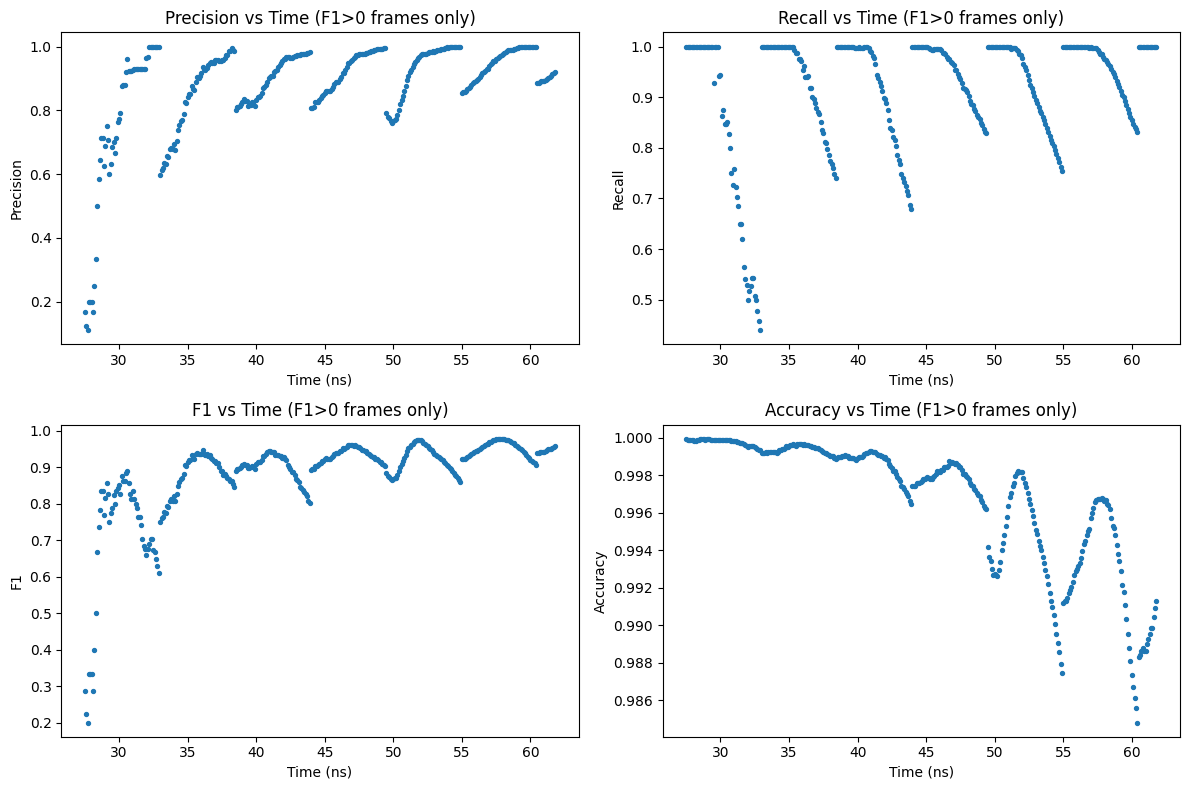

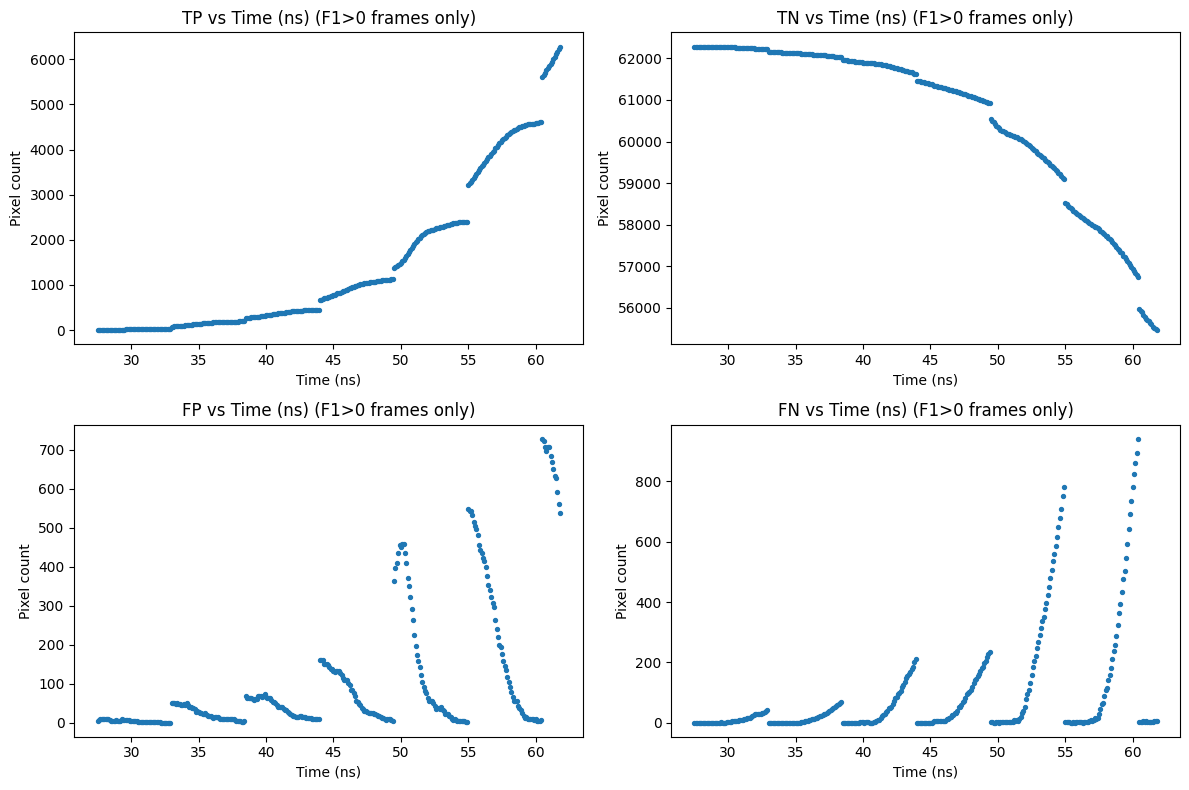

{'outdir': '/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/Metric Plots/base_test',
 'saved_paths': ['/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/Metric Plots/base_test/precision_scatter_f1_gt0.png',
  '/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/Metric Plots/base_test/recall_scatter_f1_gt0.png',
  '/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/Metric Plots/base_test/f1_scatter_f1_gt0.png',
  '/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/Metric Plots/base_test/accuracy_scatter_f1_gt0.png',
  '/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/Metric Plots/base_test/metrics_2x2_grid_scatter_f1_gt0.png',
  '/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/Metric Plots/base_test/tp_scatter_f1_gt0.png',
  '/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/Metric Plots/base_test/tn_scatter_f1_gt0.png',
  '/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML

In [65]:
info = pm.plot_per_frame_metrics(
    csv_path=csv_path_pm,
    outdir=out_dir_pm,
    time_divisor=10.0,       # frame_id/10
    show=True,
    f1_positive_only=True,   # <--- now filters to frames with F1>0
    plot_confusion_counts=True,
    confusion_logy=False,
)
info

In [52]:
import os
import numpy as np
from PIL import Image
from sklearn.metrics import confusion_matrix

PRED_DIR = "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/Metrics/sed_test"
GT_PATH  = "/scratch/gilbreth/kmartinu/microML/UNSEEN/IMGS_GT/MS5_125/MS5_125.0395.png"

def crop_to_first_black(arr, black_threshold=10):
    """Crop a grayscale image (2D array) to the bounding box of 'black' pixels."""
    mask = arr < black_threshold
    if not mask.any():
        return arr
    rows = np.where(mask.any(axis=1))[0]
    cols = np.where(mask.any(axis=0))[0]
    r0, r1 = rows[0], rows[-1]
    c0, c1 = cols[0], cols[-1]
    return arr[r0:r1+1, c0:c1+1]

def load_pred_mask(frame_id, threshold=127, fracture_is_white=True, flipud=False):
    fname = f"mask_{frame_id:06d}.png"
    path = os.path.join(PRED_DIR, fname)
    img = Image.open(path).convert("L")
    arr = np.array(img).astype(np.uint8)
    if flipud:
        arr = np.flipud(arr)
    if fracture_is_white:
        return arr > threshold
    else:
        return arr < threshold

def load_gt_mask(target_shape, threshold=127, fracture_is_white=True, flipud=False):
    img = Image.open(GT_PATH).convert("L")
    arr = np.array(img).astype(np.uint8)
    arr_crop = crop_to_first_black(arr, black_threshold=10)
    Ht, Wt = target_shape
    img_rs = Image.fromarray(arr_crop).resize((Wt, Ht), resample=Image.NEAREST)
    arr_rs = np.array(img_rs).astype(np.uint8)
    if flipud:
        arr_rs = np.flipud(arr_rs)
    if fracture_is_white:
        return arr_rs > threshold
    else:
        return arr_rs < threshold

def f1_from_masks(pred_bin, gt_bin):
    yt = gt_bin.reshape(-1).astype(np.uint8)
    yp = pred_bin.reshape(-1).astype(np.uint8)
    cm = confusion_matrix(yt, yp, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    return f1, prec, rec, tp, fp, fn, tn

for frame_id in [385, 386]:
    pred_bin = load_pred_mask(frame_id, fracture_is_white=True, flipud=False)
    gt_bin   = load_gt_mask(pred_bin.shape, fracture_is_white=True, flipud=False)

    f1, prec, rec, tp, fp, fn, tn = f1_from_masks(pred_bin, gt_bin)
    print(f"Frame {frame_id}:")
    print(f"  tp={tp}, fp={fp}, fn={fn}, tn={tn}")
    print(f"  precision={prec:.4f}, recall={rec:.4f}, F1={f1:.4f}")


Frame 385:
  tp=240, fp=32, fn=0, tn=51409
  precision=0.8824, recall=1.0000, F1=0.9375
Frame 386:
  tp=240, fp=34, fn=0, tn=51407
  precision=0.8759, recall=1.0000, F1=0.9339


In [51]:
import os
import numpy as np
from PIL import Image

# --- your paths ---
# --- paths with your actual locations ---
PRED_DIR = "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/Metrics/sed_test"
GT_PATH  = "/scratch/gilbreth/kmartinu/microML/UNSEEN/IMGS_GT/MS5_125/MS5_125.0395.png"
OUT_DIR  = "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/Metrics/sed_test/diff_masks"


os.makedirs(OUT_DIR, exist_ok=True)


def crop_to_first_black(arr, black_threshold=10):
    """
    Crop a grayscale image (2D array) to the bounding box
    where pixels are 'black' (value < black_threshold).
    """
    mask = arr < black_threshold
    if not mask.any():
        # no black pixels found -> return original
        return arr

    rows = np.where(mask.any(axis=1))[0]
    cols = np.where(mask.any(axis=0))[0]
    r0, r1 = rows[0], rows[-1]
    c0, c1 = cols[0], cols[-1]
    return arr[r0:r1+1, c0:c1+1]


def load_binary_mask_pred(path, threshold=127, flipud=False, fracture_is_white=True):
    """Load prediction PNG -> binary mask."""
    img = Image.open(path).convert("L")
    arr = np.array(img).astype(np.uint8)
    if flipud:
        arr = np.flipud(arr)
    if fracture_is_white:
        mask = arr > threshold
    else:
        mask = arr < threshold
    return mask


def load_binary_mask_gt(path, target_shape, threshold=127, flipud=False, fracture_is_white=True):
    """Load GT PNG, crop to first black pixels, resize to target_shape -> binary mask."""
    img = Image.open(path).convert("L")
    arr = np.array(img).astype(np.uint8)

    # 1) crop to first black pixels on all sides
    arr_crop = crop_to_first_black(arr, black_threshold=10)

    # 2) resize cropped region to match prediction shape
    Ht, Wt = target_shape
    img_crop = Image.fromarray(arr_crop)
    img_rs = img_crop.resize((Wt, Ht), resample=Image.NEAREST)
    arr_rs = np.array(img_rs).astype(np.uint8)

    if flipud:
        arr_rs = np.flipud(arr_rs)

    if fracture_is_white:
        mask = arr_rs > threshold
    else:
        mask = arr_rs < threshold

    return mask


def save_diff_mask(frame_id,
                   pred_prefix="mask_",
                   ext=".png",
                   threshold_pred=127,
                   threshold_gt=127,
                   fracture_is_white_pred=True,
                   fracture_is_white_gt=True,
                   flipud_pred=False,
                   flipud_gt=False):
    """
    Create and save XOR difference mask for a given frame_id.
    White pixels = locations where prediction and GT disagree.
    """
    fname = f"{frame_id:06d}{ext}"
    pred_path = os.path.join(PRED_DIR, f"{pred_prefix}{fname}")
    gt_path   = GT_PATH  # single GT image

    if not os.path.exists(pred_path):
        raise FileNotFoundError(f"Missing prediction: {pred_path}")
    if not os.path.exists(gt_path):
        raise FileNotFoundError(f"Missing ground truth: {gt_path}")

    # load prediction so we know target HxW
    pred_bin = load_binary_mask_pred(
        pred_path,
        threshold=threshold_pred,
        flipud=flipud_pred,
        fracture_is_white=fracture_is_white_pred,
    )

    # load + crop + resize GT to same HxW
    gt_bin = load_binary_mask_gt(
        gt_path,
        target_shape=pred_bin.shape,
        threshold=threshold_gt,
        flipud=flipud_gt,
        fracture_is_white=fracture_is_white_gt,
    )

    if pred_bin.shape != gt_bin.shape:
        raise ValueError(f"Shape mismatch even after crop/resize: pred {pred_bin.shape}, gt {gt_bin.shape}")

    # XOR: True where they differ
    diff = np.logical_xor(pred_bin, gt_bin)

    diff_u8 = diff.astype(np.uint8) * 255
    out_path = os.path.join(OUT_DIR, f"diff_{fname}")
    Image.fromarray(diff_u8).save(out_path)
    print(f"Saved: {out_path}")


# ---- generate for your two highlighted frames ----
for frame_id in [385, 386]:
    save_diff_mask(
        frame_id,
        fracture_is_white_pred=True,  # change to False if fracture is black in preds
        fracture_is_white_gt=True,    # change to False if fracture is black in GT
        flipud_pred=False,
        flipud_gt=False,
    )


Saved: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/Metrics/sed_test/diff_masks/diff_000385.png
Saved: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/Metrics/sed_test/diff_masks/diff_000386.png


## Plotting metrics of frame with the worst F1
For evaluating the worst prediction

In [170]:
csv_path = f"/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/Metrics/{RUN_TAG}/{TEST_NAME}/per_frame_metrics.csv"

In [171]:
res = wf.top_worst_cases_from_csv(
    csv_path,
    top_k=50,
    exclude_first_frame=True,
    min_gt_pos_pixels=1,  # set to 50 or 200 to ignore tiny GT positives
    print_tables=True,
)

# res["case_A"].head(10), res["case_B"].head(10) are the full DataFrames (sorted)



CASE A (GT fracture present, _gt_pos >= 1): TOP 50 worst by MIN f1
 frame_id       f1 mode precision   recall accuracy   tp    tn  fp  fn  _gt_pos _fp_rate  batch  i_in_batch
      264 0.000000   AR  0.000000 0.000000 0.999981    0 51680   0   1        1 0.000000     52           4
      265 0.000000   AR  0.000000 0.000000 0.999961    0 51679   0   2        2 0.000000     53           0
      266 0.000000   AR  0.000000 0.000000 0.999961    0 51679   0   2        2 0.000000     53           1
      267 0.000000   AR  0.000000 0.000000 0.999961    0 51679   0   2        2 0.000000     53           2
      268 0.000000   AR  0.000000 0.000000 0.999961    0 51679   0   2        2 0.000000     53           3
      269 0.000000   AR  0.000000 0.000000 0.999942    0 51678   0   3        3 0.000000     53           4
      270 0.000000   AR  0.000000 0.000000 0.999942    0 51678   0   3        3 0.000000     54           0
      271 0.000000   AR  0.000000 0.000000 0.999942    0 51678   0  

## Plotting loss

In [225]:
# Path for the csv training log you want to plot
#csv1 = "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/MODEL/pressure_20260215_182728/training_log.csv"
#csv2 = "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/MODEL/pressure_20260216_120602/training_log.csv"
#csv3 = "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS//MODEL/pressure_20260216_173723/training_log.csv"




#csv1 = "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/MODEL/vonmises_20260215_183351/training_log.csv"
#csv2 = "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/MODEL/vonmises_20260216_121240/training_log.csv"
#csv3 = "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS//MODEL/vonmises_20260216_185538/training_log.csv"

# csv1 = "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/MODEL/sed_20260215_183409/training_log.csv"
# csv2 = "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/MODEL/sed_20260216_121259/training_log.csv"
# csv3 = "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS//MODEL/sed_20260216_185557/training_log.csv"

csv1 = "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/MODEL/NOREBOUND_NEW/sed_20260322_175447_LARGER_RANGE/training_log.csv"
csv2 = "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/MODEL/base_20260302_175353_LARGER_RANGE/training_log.csv"



#csv1 = "/scratch/gilbreth/kmartinu/microML/training_log_undef.csv"


In [227]:
out = lc.plot_loss_curves_to_metrics(
    [csv1, csv2],#[csv1, csv2, csv3],
    append_csvs=True,
    max_epoch=116,
    title="",
    n_xticks=10,
    title_fontsize=22,
    label_fontsize=16,
    tick_fontsize=16,
    legend_fontsize=16,
    show=True,
)


print("Saved:", out)

NameError: name '_infer_run_name_from_model' is not defined

In [ ]:
# for just one plot

# csv1 = "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/MODEL/RUN_A/training_log_part1.csv"

# out = lc.plot_loss_curves_to_metrics(
#     csv1,
#     xtick_step=1,
#     show=False,
# )

# print("Saved:", out)